# RAID Dataset — Exploratory Data Analysis

This notebook explores the RAID benchmark dataset before any modeling.
We cover:
1. Basic shape and schema
2. Label balance (human vs AI)
3. Domain distribution
4. Model distribution
5. Adversarial attack type breakdown
6. Decoding strategy breakdown
7. Text length analysis
8. Cross-tabulations (domain x model, domain x attack)
9. Data quality checks

In [1]:
import sys
sys.path.insert(0, '..')  # make src importable when running from notebooks/

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.loader import load_raid, filter_no_attack

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
# Load a 500k-row sample of train for speed (full train is ~11 GB).
# Set train_nrows=None to load everything (takes several minutes).
TRAIN_SAMPLE = 500_000

train_df, test_df = load_raid('../data/raw', train_nrows=TRAIN_SAMPLE)

print(f'Train: {len(train_df):,} rows  |  {train_df.shape[1]} columns')
print(f'Test:  {len(test_df):,} rows  |  {test_df.shape[1]} columns')

Train: 500,000 rows  |  12 columns
Test:  672,000 rows  |  2 columns


In [3]:
train_df.head(3)

,id,adv_source_id,source_id,model,decoding,repetition_penalty,attack,domain,title,prompt,generation,label
0,e5e058ce-be2b-459d-af36-32532aaba5ff,e5e058ce-be2b-459d-af36-32532aaba5ff,e5e058ce-be2b-459d-af36-32532aaba5ff,human,NaN,NaN,none,abstracts,FUTURE-AI: Guiding Principles and Consensus Re...,NaN,The recent advancements in artificial intellig...,0
1,f95b107b-d176-4af5-90f7-4d0bb20caf93,f95b107b-d176-4af5-90f7-4d0bb20caf93,f95b107b-d176-4af5-90f7-4d0bb20caf93,human,NaN,NaN,none,abstracts,EdgeFlow: Achieving Practical Interactive Segm...,NaN,High-quality training data play a key role in ...,0
2,856d8972-9e3d-4544-babc-0fe16f21e04d,856d8972-9e3d-4544-babc-0fe16f21e04d,856d8972-9e3d-4544-babc-0fe16f21e04d,human,NaN,NaN,none,abstracts,Semi-supervised Contrastive Learning for Label...,NaN,The success of deep learning methods in medica...,0


In [4]:
train_df.dtypes

id                    object
adv_source_id         object
source_id             object
model                 object
decoding              object
repetition_penalty    object
attack                object
domain                object
title                 object
prompt                object
generation            object
label                  int64
dtype: object

In [5]:
# Missing values
print('=== Train missing values ===')
print(train_df.isnull().sum())
print()
print('=== Test missing values ===')
print(test_df.isnull().sum())

=== Train missing values ===


id                        0
adv_source_id             0
source_id                 0
model                     0
decoding              19426
repetition_penalty    19426
attack                    0
domain                    0
title                     0
prompt                19426
generation                0
label                     0
dtype: int64

=== Test missing values ===


id            0
generation    0
dtype: int64


## 2. Label Balance

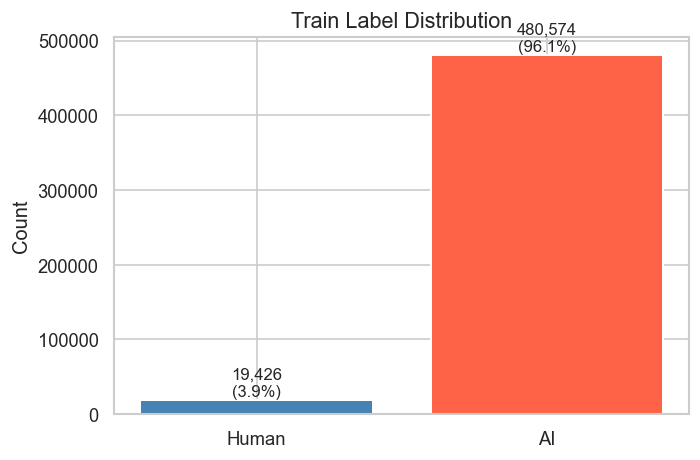

In [6]:
# test.csv has no label/model column (labels are withheld by the benchmark)
# Show label balance for train only
fig, ax = plt.subplots(figsize=(6, 4))

counts = train_df['label'].value_counts().sort_index()
labels_map = {0: 'Human', 1: 'AI'}
ax.bar([labels_map[i] for i in counts.index], counts.values,
       color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.2)
ax.set_title('Train Label Distribution', fontsize=13)
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.01, f'{v:,}\n({v/len(train_df)*100:.1f}%)',
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/label_balance.png', bbox_inches='tight')
plt.show()

## 3. Domain Distribution

In [7]:
domain_counts = train_df['domain'].value_counts()
print(domain_counts.to_string())

domain
abstracts    500000


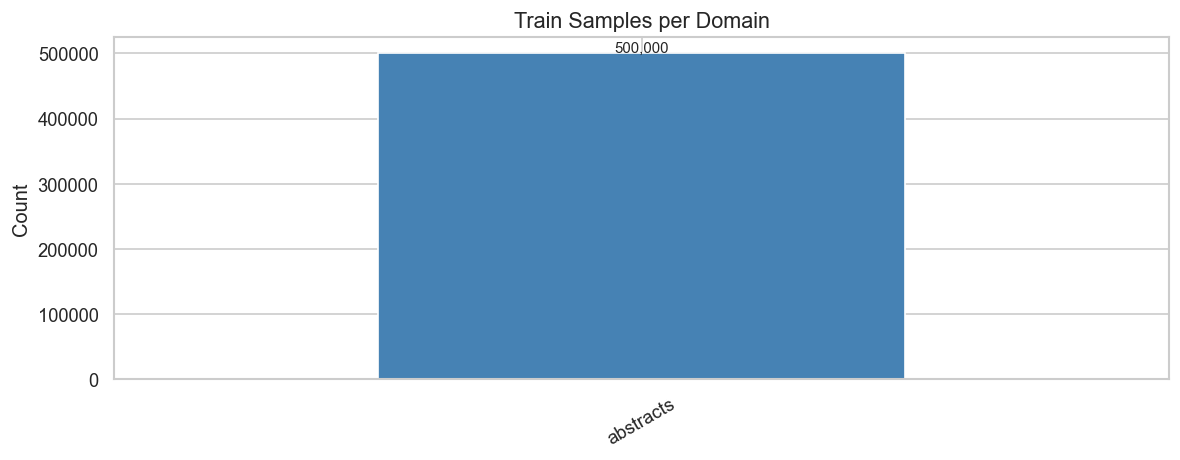

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
domain_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Train Samples per Domain', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(domain_counts.values):
    ax.text(i, v + domain_counts.max() * 0.005, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/domain_distribution.png', bbox_inches='tight')
plt.show()

## 4. Model Distribution

In [9]:
model_counts = train_df['model'].value_counts()
print(model_counts.to_string())

model
llama-chat      63576
gpt2            63576
mistral         63576
mistral-chat    63576
mpt             60044
mpt-chat        60044
gpt3            21414
cohere          21192
chatgpt         21192
gpt4            21192
cohere-chat     21192
human           19426


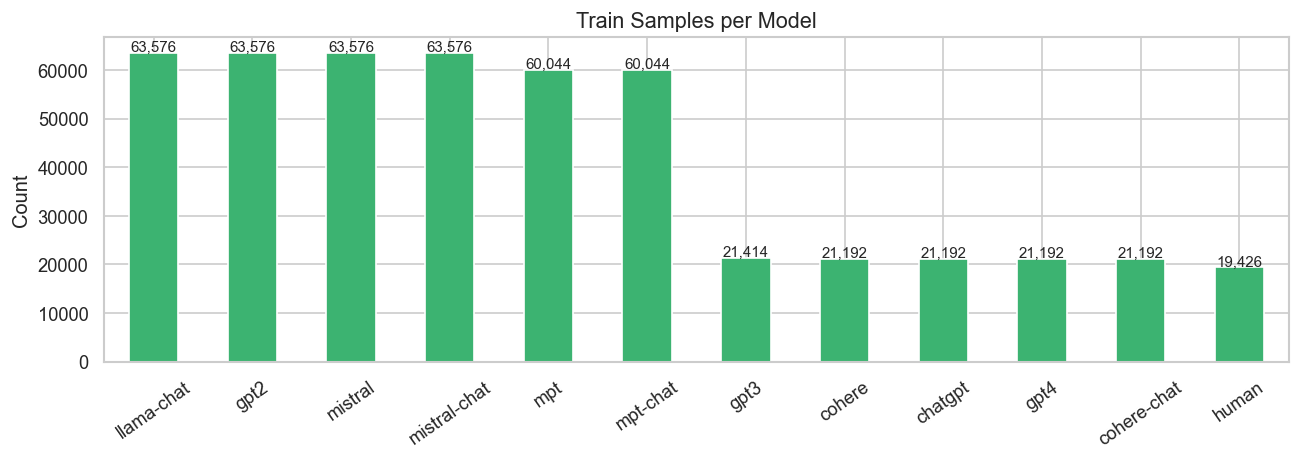

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
model_counts.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Train Samples per Model', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=35)
for i, v in enumerate(model_counts.values):
    ax.text(i, v + model_counts.max() * 0.005, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/model_distribution.png', bbox_inches='tight')
plt.show()

## 5. Adversarial Attack Type Breakdown

In [11]:
attack_counts = train_df['attack'].value_counts()
print(attack_counts.to_string())

attack
none                      61810
whitespace                61810
upper_lower               61810
synonym                   61810
paraphrase                61810
number                    61810
insert_paragraphs         37308
perplexity_misspelling    22958
homoglyph                 22958
article_deletion          22958
alternative_spelling      22958


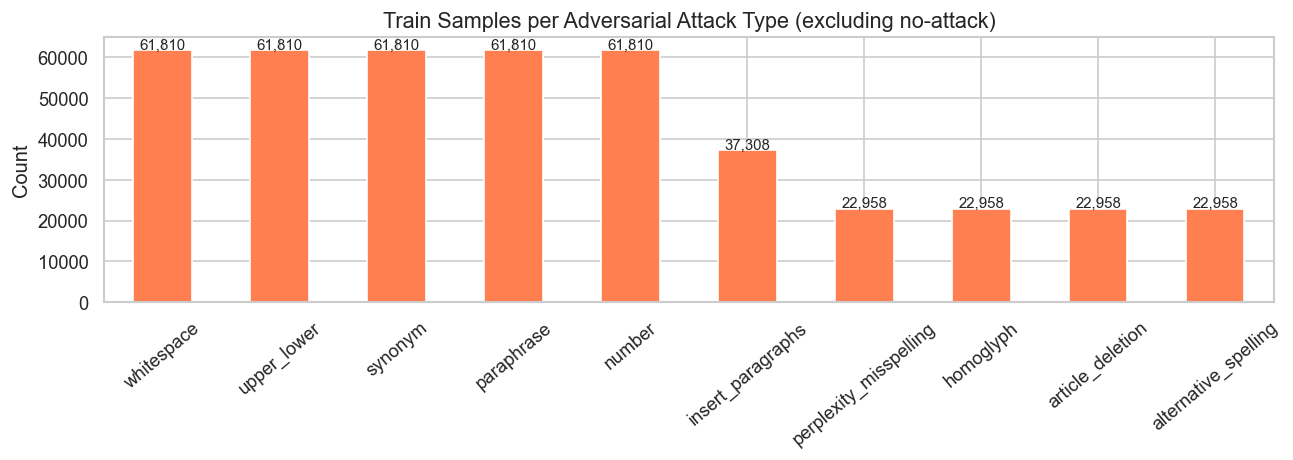

Rows with no attack: 12.4%


In [12]:
# Separate 'none' from actual attacks for clearer visualization
attack_only = attack_counts[attack_counts.index != 'none']

fig, ax = plt.subplots(figsize=(11, 4))
attack_only.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Train Samples per Adversarial Attack Type (excluding no-attack)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=40)
for i, v in enumerate(attack_only.values):
    ax.text(i, v + attack_only.max() * 0.005, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/attack_distribution.png', bbox_inches='tight')
plt.show()

no_attack_pct = (train_df['attack'] == 'none').mean() * 100
print(f'Rows with no attack: {no_attack_pct:.1f}%')

## 6. Decoding Strategy Breakdown

decoding
greedy      240287
sampling    240287


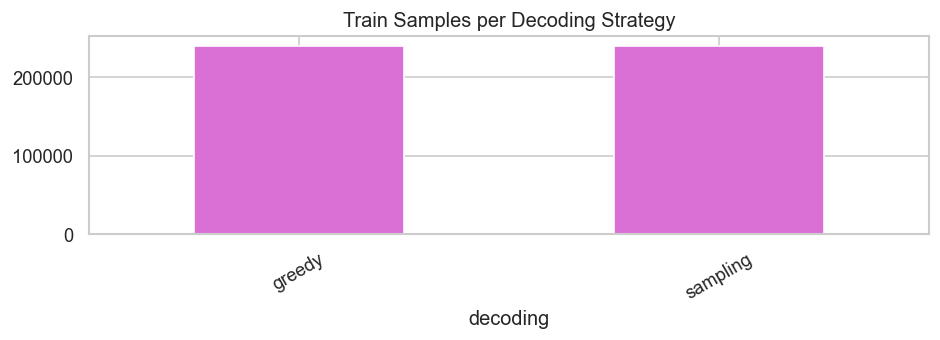

In [13]:
if 'decoding' in train_df.columns:
    dec_counts = train_df['decoding'].value_counts()
    print(dec_counts.to_string())
    dec_counts.plot(kind='bar', figsize=(8, 3), color='orchid', edgecolor='white',
                    title='Train Samples per Decoding Strategy')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig('../results/decoding_distribution.png', bbox_inches='tight')
    plt.show()
else:
    print('No decoding column found -- check column names:', train_df.columns.tolist())

## 7. Text Length Analysis

In [14]:
# Use a sample for speed if the dataset is large
sample = train_df.sample(min(50_000, len(train_df)), random_state=42).copy()
sample['char_len'] = sample['generation'].str.len()
sample['word_len'] = sample['generation'].str.split().str.len()

print(sample[['char_len', 'word_len']].describe())

        char_len   word_len
count 50000.0000 50000.0000
mean   1274.3029   188.4562
std     664.3210   103.7014
min       3.0000     1.0000
25%     752.0000   108.0000
50%    1045.0000   151.0000
75%    1805.0000   262.0000
max    6916.0000  2985.0000


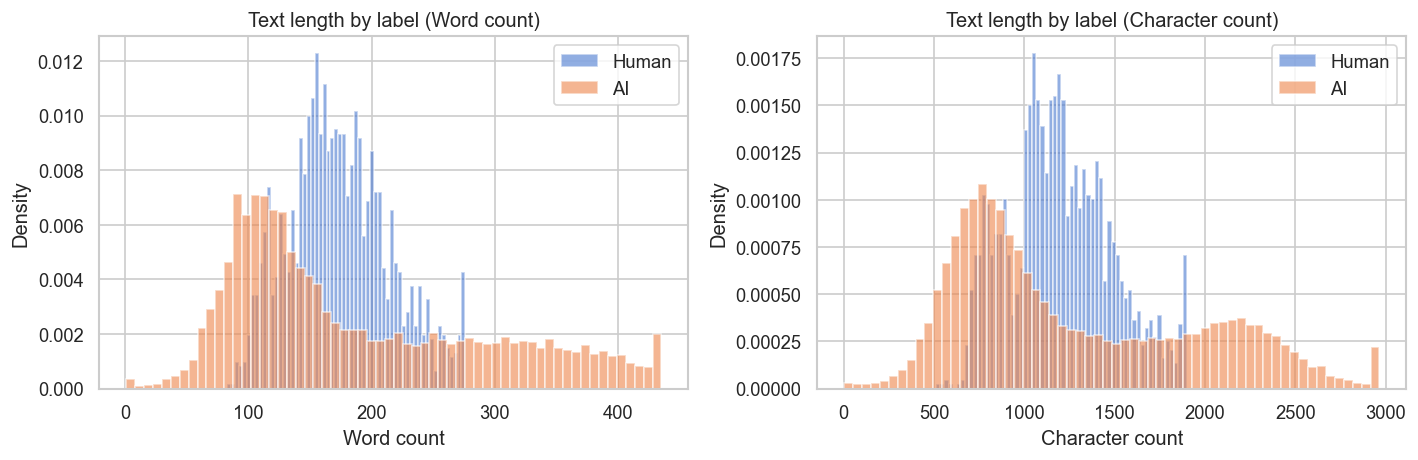

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, xlabel in zip(axes,
                            ['word_len', 'char_len'],
                            ['Word count', 'Character count']):
    for label, grp in sample.groupby('label'):
        name = 'AI' if label == 1 else 'Human'
        clip = grp[col].clip(upper=grp[col].quantile(0.99))
        ax.hist(clip, bins=60, alpha=0.6, label=name, density=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(f'Text length by label ({xlabel})')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/text_length_by_label.png', bbox_inches='tight')
plt.show()

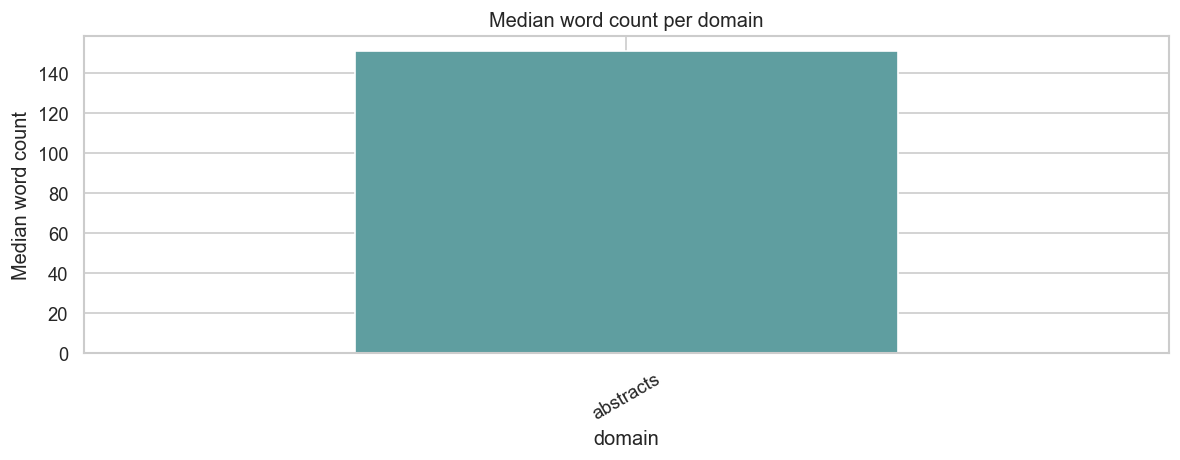

In [16]:
# Median word length by domain
domain_len = (sample.groupby('domain')['word_len']
              .median().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
domain_len.plot(kind='bar', ax=ax, color='cadetblue', edgecolor='white')
ax.set_title('Median word count per domain')
ax.set_ylabel('Median word count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../results/word_length_by_domain.png', bbox_inches='tight')
plt.show()

## 8. Cross-tabulations

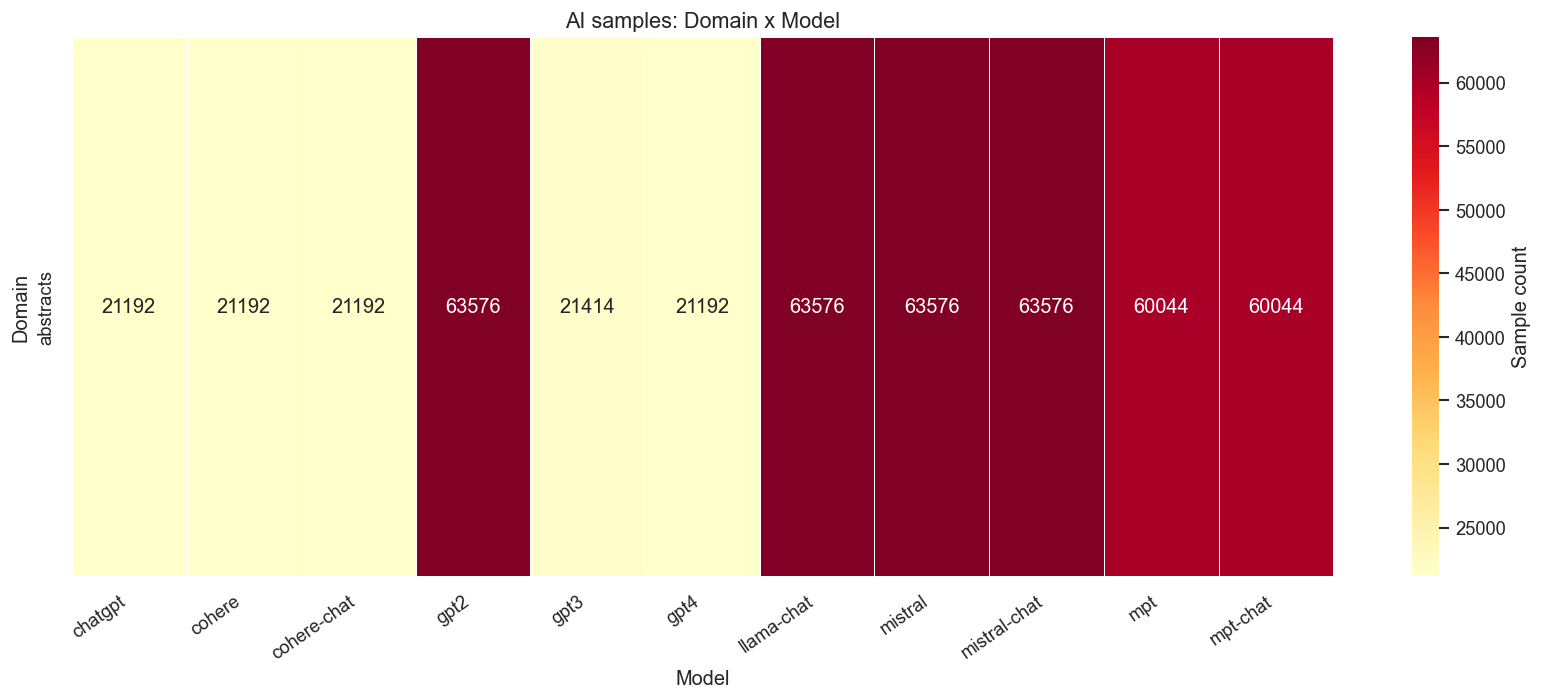

In [17]:
# Domain x Model heatmap (count of AI samples)
ai_df = train_df[train_df['label'] == 1]
cross = pd.crosstab(ai_df['domain'], ai_df['model'])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Sample count'})
ax.set_title('AI samples: Domain x Model', fontsize=13)
ax.set_xlabel('Model')
ax.set_ylabel('Domain')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('../results/domain_x_model_heatmap.png', bbox_inches='tight')
plt.show()

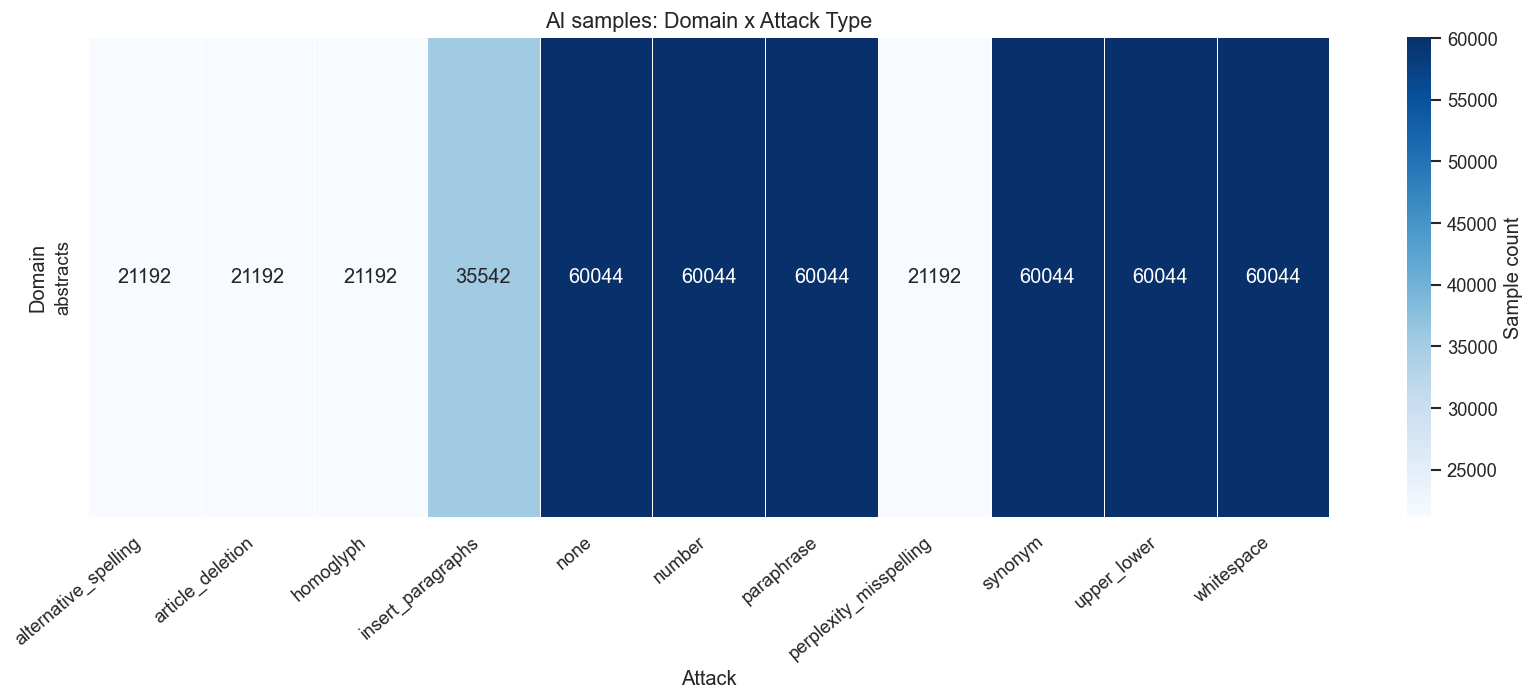

In [18]:
# Domain x Attack heatmap
cross_atk = pd.crosstab(ai_df['domain'], ai_df['attack'])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cross_atk, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Sample count'})
ax.set_title('AI samples: Domain x Attack Type', fontsize=13)
ax.set_xlabel('Attack')
ax.set_ylabel('Domain')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('../results/domain_x_attack_heatmap.png', bbox_inches='tight')
plt.show()

## 9. Data Quality Checks

In [19]:
print('=== Duplicate generations in train ===')
n_dups = train_df['generation'].duplicated().sum()
print(f'  {n_dups:,} duplicates ({n_dups/len(train_df)*100:.2f}%)')

print()
print('=== Empty / very short generations (< 10 chars) ===')
short = (train_df['generation'].str.len() < 10).sum()
print(f'  {short:,} rows')

print()
print('=== Unique values per key column ===')
for col in ['domain', 'model', 'attack', 'label']:
    if col in train_df.columns:
        print(f'  {col}: {sorted(train_df[col].unique().tolist())}')

=== Duplicate generations in train ===
  64,846 duplicates (12.97%)

=== Empty / very short generations (< 10 chars) ===
  55 rows

=== Unique values per key column ===
  domain: ['abstracts']
  model: ['chatgpt', 'cohere', 'cohere-chat', 'gpt2', 'gpt3', 'gpt4', 'human', 'llama-chat', 'mistral', 'mistral-chat', 'mpt', 'mpt-chat']
  attack: ['alternative_spelling', 'article_deletion', 'homoglyph', 'insert_paragraphs', 'none', 'number', 'paraphrase', 'perplexity_misspelling', 'synonym', 'upper_lower', 'whitespace']
  label: [0, 1]


In [20]:
print('EDA complete. Figures saved to ../results/')

EDA complete. Figures saved to ../results/
